# Etapa 2 — MLP vs Baselines: Comparação Financeira End-to-End

**Entregáveis oficiais desta etapa:**
1. Tabela comparativa de modelos com métricas financeiras
2. MLP treinada com PyTorch (arquitetura, early stopping, batching)
3. Artefatos completos registrados no MLflow

**Boas práticas implementadas:**
- Seeds fixadas para reprodutibilidade (torch + numpy + random)
- Validação cruzada estratificada (StratifiedKFold, 5-fold)
- Testes automatizados (≥3: smoke, schema, contrato)
- Logging estruturado — zero `print()`
- Linting ruff sem erros
- Versionamento de dataset no MLflow (MD5 + shape + churn_rate)
- Model Card com limitações e vieses

## 0. Imports e configuração

In [1]:
# stdlib
from __future__ import annotations

import hashlib
import json as json_mod
import warnings

# terceiros
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# internos
from churn_telecom.config import (
    DEVICE,
    MLFLOW_EXPERIMENT,
    PROJECT_ROOT,
    RANDOM_STATE,
    get_logger,
    setup_mlflow,
)
from churn_telecom.models.trainer import (
    EarlyStopping,
    TrainHistory,
    TrainerConfig,
    _compute_auc,
    _set_seed,
    _to_tensor,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logger = get_logger("05_etapa2_completa")

# ── Custos reais calibrados ───────────────────────────────────────────────────
COST_FN: float = 2845.0
COST_FP: float = 73.52
COST_RATIO: float = COST_FN / COST_FP
SLO_RECALL_MIN: float = 0.70
CV_N_SPLITS: int = 5
SKF = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ── Paths autocontidos ────────────────────────────────────────────────────────
FIGS_DIR = PROJECT_ROOT / "reports" / "baselines"
MODELS_DIR = PROJECT_ROOT / "models"
FIGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logger.info(
    "Notebook Etapa 2 | device=%s | FN=US$%.0f | FP=US$%.0f | ratio=%.1fx | cv=%d-fold",
    DEVICE, COST_FN, COST_FP, COST_RATIO, CV_N_SPLITS,
)

23:01:08 | INFO | Notebook Etapa 2 | device=cpu | FN=US$2845 | FP=US$74 | ratio=38.7x | cv=5-fold
INFO:05_etapa2_completa:Notebook Etapa 2 | device=cpu | FN=US$2845 | FP=US$74 | ratio=38.7x | cv=5-fold


## 1. Carregar e versionar o dataset

In [2]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

X_full = np.load(DATA_PROCESSED / "features.npy").astype(np.float32)
y_full = np.load(DATA_PROCESSED / "target.npy").astype(np.float32)

DATASET_META: dict = {
    "features_md5": hashlib.md5((DATA_PROCESSED / "features.npy").read_bytes()).hexdigest(),
    "target_md5": hashlib.md5((DATA_PROCESSED / "target.npy").read_bytes()).hexdigest(),
    "n_samples": int(X_full.shape[0]),
    "n_features": int(X_full.shape[1]),
    "churn_rate": round(float(y_full.mean()), 4),
    "source": "data/processed/features.npy",
}
INPUT_DIM: int = X_full.shape[1]

logger.info(
    "Dataset | shape=%s | churn=%.2f%% | md5=%s",
    X_full.shape, y_full.mean() * 100, DATASET_META["features_md5"][:8],
)

23:01:08 | INFO | Dataset | shape=(6800, 30) | churn=51.01% | md5=c5874d93
INFO:05_etapa2_completa:Dataset | shape=(6800, 30) | churn=51.01% | md5=c5874d93


## 2. Split holdout + testes automatizados

In [3]:
_set_seed(RANDOM_STATE)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE,
)
pos_weight_classes: float = float((y_dev == 0).sum() / max((y_dev == 1).sum(), 1))

logger.info(
    "Split | dev=%d | test=%d | churn_dev=%.2f%% | pos_weight=%.2f",
    len(X_dev), len(X_test), y_dev.mean() * 100, pos_weight_classes,
)

# ── SMOKE TEST 1 — integridade do dataset ─────────────────────────────────────
assert X_full.ndim == 2 and y_full.ndim == 1, "Dimensões inválidas"
assert len(X_full) == len(y_full), "X e y com tamanhos diferentes"
assert np.isnan(X_full).sum() == 0, "NaN encontrado"
assert X_full.dtype == np.float32, f"dtype errado: {X_full.dtype}"
assert set(np.unique(y_full)).issubset({0.0, 1.0}), "Classes inválidas"
logger.info("[SMOKE TEST 1] integridade — OK")

# ── SCHEMA TEST — split estratificado ─────────────────────────────────────────
assert X_dev.shape[1] == X_test.shape[1] == INPUT_DIM, "Features inconsistentes"
assert abs(y_dev.mean() - y_test.mean()) < 0.02, "Estratificação falhou"
assert 0.74 <= len(X_dev) / len(X_full) <= 0.86, "Proporção dev/total fora de 80%"
logger.info("[SCHEMA TEST] split — OK | delta_churn=%.4f", abs(y_dev.mean() - y_test.mean()))

23:01:08 | INFO | Split | dev=5440 | test=1360 | churn_dev=51.01% | pos_weight=0.96
INFO:05_etapa2_completa:Split | dev=5440 | test=1360 | churn_dev=51.01% | pos_weight=0.96
23:01:08 | INFO | [SMOKE TEST 1] integridade — OK
INFO:05_etapa2_completa:[SMOKE TEST 1] integridade — OK
23:01:08 | INFO | [SCHEMA TEST] split — OK | delta_churn=0.0002
INFO:05_etapa2_completa:[SCHEMA TEST] split — OK | delta_churn=0.0002


## 3. Fórmula de eficiência financeira — a lógica central

### Por que custo total e não F1?

O F1-score trata falsos positivos e falsos negativos como igualmente graves. Na operadora de telecom, perder um cliente que ia cancelar (FN) custa **US\$2.903** em CLV perdido, enquanto enviar uma campanha de retenção desnecessária (FP) custa apenas **US\$50**. A razão é 58×.

### A fórmula

$$\text{Custo Total} = FN \times \$2{,}903 + FP \times \$50$$

O modelo vencedor é o que **minimiza essa soma**, respeitando o SLO operacional de **Recall ≥ 70%** (contrato com a diretoria).

### Como o threshold ótimo é calculado

Para cada modelo, varremos `threshold ∈ [0.05, 0.94]` em passos de 0.01. Para cada threshold:
1. Calculamos a matriz de confusão (TP, FP, TN, FN)
2. Calculamos o custo total com a fórmula acima
3. Verificamos se `Recall ≥ 70%` (SLO)
4. Selecionamos o threshold com **menor custo entre os que atendem o SLO**

### Como o pos_weight alinha a MLP ao custo

O `pos_weight` na `BCEWithLogitsLoss` multiplica a loss dos exemplos positivos (churners). Com `pos_weight = 58`, o gradiente de cada FN pesa 58× mais que o de cada FP — o modelo "sente" a assimetria financeira durante o backprop.

### Resultado esperado

O modelo ideal captura quase todos os churners (recall alto → FN baixo), mesmo aceitando mais falsos alarmes (FP alto), porque `58 × US$50 = US$2.900 ≈ custo de 1 FN`. Cada FN evitado vale 58 FPs.

## 4. Definição da arquitetura — ChurnMLPv2

Escolhas arquiteturais documentadas:
- **LayerNorm** em vez de BatchNorm1d: normaliza por amostra, estável com qualquer batch size
- **ReLU**: ativação padrão para redes feedforward — sparse, rápida, sem vanishing gradient
- **Dropout**: regularização estocástica entre camadas
- **Skip connection** (opcional): projeta input direto para última hidden, preserva sinal
- **Saída logit puro**: BCEWithLogitsLoss aplica sigmoid internamente (numericamente estável)
- **Inicialização Kaiming-Normal**: calibrada para ReLU (variância = 2/fan_in)

In [4]:
class ChurnMLPv2(nn.Module):
    """MLP para classificação de churn em dados tabulares.

    Arquitetura:
        Input(n) → [Linear → LayerNorm → ReLU → Dropout] × L → Linear(1) → logit

    Args:
        input_dim: número de features de entrada
        hidden_dims: lista com dimensão de cada camada oculta, ex: [64, 32]
        dropout: taxa de dropout entre camadas (default: 0.3)
        use_skip: se True, adiciona conexão residual input → última hidden
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        dropout: float = 0.3,
        use_skip: bool = False,
    ) -> None:
        super().__init__()
        if input_dim <= 0:
            raise ValueError(f"input_dim deve ser > 0, recebeu {input_dim}")
        if not hidden_dims:
            raise ValueError("hidden_dims não pode ser vazio")
        if not 0.0 <= dropout < 1.0:
            raise ValueError(f"dropout deve estar em [0, 1), recebeu {dropout}")

        self.use_skip = use_skip
        self.input_dim = input_dim

        layers: list[nn.Module] = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend(
                [nn.Linear(prev_dim, h_dim), nn.LayerNorm(h_dim), nn.ReLU(), nn.Dropout(dropout)]
            )
            prev_dim = h_dim

        self.hidden = nn.Sequential(*layers)
        if use_skip:
            self.skip_proj = nn.Linear(input_dim, hidden_dims[-1])
        self.output = nn.Linear(hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.hidden(x)
        if self.use_skip:
            h = h + self.skip_proj(x)
        return self.output(h)


def build_mlp_v2(
    input_dim: int, hidden_dims: list[int], dropout: float = 0.3,
    device: str = "cpu", seed: int = 42, use_skip: bool = False,
) -> ChurnMLPv2:
    """Factory com seed fixa antes da inicialização dos pesos."""
    _set_seed(seed)
    model = ChurnMLPv2(input_dim, hidden_dims, dropout, use_skip).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger.info("MLPv2 | dims=%s | params=%d | skip=%s | seed=%d", hidden_dims, n_params, use_skip, seed)
    return model


# ── SMOKE TEST 2 — forward pass ───────────────────────────────────────────────
_sm = build_mlp_v2(INPUT_DIM, [64, 32], 0.3, "cpu", RANDOM_STATE)
_so = _sm(torch.randn(4, INPUT_DIM))
assert _so.shape == (4, 1), f"shape errado: {_so.shape}"
assert not torch.isnan(_so).any(), "NaN na saída"
_np = sum(p.numel() for p in _sm.parameters() if p.requires_grad)
logger.info("[SMOKE TEST 2] forward pass — OK | params=%d | ratio=%.1f", _np, len(X_dev) / _np)
del _sm, _so

23:01:08 | INFO | MLPv2 | dims=[64, 32] | params=4289 | skip=False | seed=42
INFO:05_etapa2_completa:MLPv2 | dims=[64, 32] | params=4289 | skip=False | seed=42
23:01:08 | INFO | [SMOKE TEST 2] forward pass — OK | params=4289 | ratio=1.3
INFO:05_etapa2_completa:[SMOKE TEST 2] forward pass — OK | params=4289 | ratio=1.3


## 5. Loop de treinamento — ChurnTrainerV2

Implementação do loop com:
- **Batching** via `DataLoader` (mini-batch SGD)
- **Early stopping** monitorando `val_loss` com patience configurável
- **Gradient clipping** (`max_norm=1.0`) para estabilidade
- **ReduceLROnPlateau** scheduler (reduz LR quando val_loss estagna)
- **Label smoothing** opcional (0→0.025, 1→0.975)
- **Otimizador AdamW** (weight decay matematicamente correto)

In [5]:
class ChurnTrainerV2:
    """Trainer com AdamW, label smoothing, early stopping e batching.

    O loop de treinamento:
    1. Para cada época:
       a. Forward pass em mini-batches (train)
       b. Calcula loss com BCEWithLogitsLoss(pos_weight)
       c. Backward + clip_grad_norm + optimizer.step
       d. Avalia no val set (sem gradientes)
       e. Scheduler ajusta LR se val_loss estagnou
       f. Early stopping salva melhor checkpoint e para se platô > patience
    2. Restaura pesos do melhor checkpoint
    """

    def __init__(
        self, model: nn.Module, config: TrainerConfig, label_smoothing: float = 0.0,
    ) -> None:
        _set_seed(config.seed)
        self.model = model
        self.cfg = config
        self.device = torch.device(config.device)
        self.model.to(self.device)
        self.label_smoothing = label_smoothing

        pos_weight = (
            torch.tensor([config.pos_weight], device=self.device)
            if config.pos_weight is not None else None
        )
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="min", patience=5, factor=0.5,
        )
        self._es = EarlyStopping(patience=config.patience, min_delta=config.min_delta)
        self.history = TrainHistory()

    def _smooth(self, y: np.ndarray) -> np.ndarray:
        if self.label_smoothing <= 0:
            return y
        s = self.label_smoothing
        return y * (1.0 - s) + s / 2.0

    def _loader(self, X, y, shuffle=True):
        return DataLoader(
            TensorDataset(_to_tensor(X), _to_tensor(y)),
            batch_size=self.cfg.batch_size, shuffle=shuffle, drop_last=False,
        )

    def _epoch(self, loader, train=True):
        self.model.train() if train else self.model.eval()
        total, logits_all, tgts = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                logits = self.model(xb).squeeze(1)
                loss = self.criterion(logits, yb)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total += loss.item() * len(yb)
                logits_all.append(logits.detach())
                tgts.append(yb.detach())
        return total / len(loader.dataset), _compute_auc(torch.cat(logits_all), torch.cat(tgts))

    def fit(self, X_train, y_train, X_val, y_val) -> TrainHistory:
        tr_loader = self._loader(X_train, self._smooth(y_train))
        vl_loader = self._loader(X_val, y_val, shuffle=False)
        logger.info("fit | epochs=%d | batch=%d | train=%d | val=%d",
                     self.cfg.epochs, self.cfg.batch_size, len(X_train), len(X_val))

        for epoch in range(1, self.cfg.epochs + 1):
            tr_l, tr_a = self._epoch(tr_loader, True)
            vl_l, vl_a = self._epoch(vl_loader, False)
            self.scheduler.step(vl_l)
            self.history.train_loss.append(tr_l)
            self.history.val_loss.append(vl_l)
            self.history.train_auc.append(tr_a)
            self.history.val_auc.append(vl_a)

            mlflow.log_metrics({"train_loss": tr_l, "val_loss": vl_l, "val_auc": vl_a}, step=epoch)

            if epoch % 25 == 0 or epoch == 1:
                logger.info("epoch %03d | tr=%.4f | vl=%.4f | auc=%.4f", epoch, tr_l, vl_l, vl_a)

            if self._es.step(vl_l, self.model):
                self.history.stopped_early = True
                self.history.best_epoch = epoch - self.cfg.patience
                logger.info("early stop | epoch=%d | best~=%d", epoch, self.history.best_epoch)
                break
        else:
            self.history.best_epoch = self.cfg.epochs

        self._es.restore_best(self.model)
        return self.history

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            return torch.sigmoid(self.model(_to_tensor(X).to(self.device)).squeeze(1)).cpu().numpy()


logger.info("ChurnTrainerV2 definido")

23:01:08 | INFO | ChurnTrainerV2 definido
INFO:05_etapa2_completa:ChurnTrainerV2 definido


## 6. Funções auxiliares — métricas, threshold, CV e plots

In [6]:
def compute_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)
    f1 = 2 * prec * recall / max(prec + recall, 1e-9)
    return {
        "threshold": threshold, "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "recall": recall, "precision": prec, "f1": f1,
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "cost_fn": fn * COST_FN, "cost_fp": fp * COST_FP,
        "cost_total": fn * COST_FN + fp * COST_FP,
        "net_value": tp * (COST_FN - COST_FP) - fp * COST_FP,
        "slo_ok": recall >= SLO_RECALL_MIN,
    }


def find_best_threshold(y_true, y_proba):
    rows = [compute_metrics(y_true, y_proba, t) for t in np.arange(0.05, 0.95, 0.01)]
    df = pd.DataFrame(rows)
    slo = df[df["slo_ok"]]
    src = slo if not slo.empty else df
    return float(src.loc[src["cost_total"].idxmin(), "threshold"]), df


def save_plots(y_true, y_proba, y_pred, model_name, figs_dir):
    """Salva ROC, PR-AUC e Confusion Matrix em figs_dir."""
    figs_dir.mkdir(parents=True, exist_ok=True)

    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax_roc, name=model_name)
    ax_roc.set_title(f"ROC — {model_name}")
    ax_roc.grid(alpha=0.3)
    fig_roc.tight_layout()
    fig_roc.savefig(figs_dir / f"{model_name}_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.close(fig_roc)

    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax_pr, name=model_name)
    ax_pr.set_title(f"PR-AUC — {model_name}")
    ax_pr.grid(alpha=0.3)
    fig_pr.tight_layout()
    fig_pr.savefig(figs_dir / f"{model_name}_pr_curve.png", dpi=150, bbox_inches="tight")
    plt.close(fig_pr)

    fig_cm, ax_cm = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=["Não Churn", "Churn"], ax=ax_cm, cmap="Blues",
    )
    ax_cm.set_title(f"Confusion Matrix — {model_name}")
    fig_cm.tight_layout()
    fig_cm.savefig(figs_dir / f"{model_name}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.close(fig_cm)

    logger.info("Plots salvos | %s | %s", model_name, figs_dir)


def evaluate_and_log(
    model_name, y_true, y_proba, figs_dir, extra_params=None, extra_metrics=None,
):
    """Fluxo completo: threshold → métricas → plots → MLflow."""
    best_t, _ = find_best_threshold(y_true, y_proba)
    m = compute_metrics(y_true, y_proba, best_t)
    y_pred = (y_proba >= best_t).astype(int)

    save_plots(y_true, y_proba, y_pred, model_name, figs_dir)

    for art in ["roc_curve", "pr_curve", "confusion_matrix"]:
        p = figs_dir / f"{model_name}_{art}.png"
        if p.exists():
            mlflow.log_artifact(str(p), "plots")

    mlflow.log_metrics({
        "test_recall": m["recall"], "test_precision": m["precision"], "test_f1": m["f1"],
        "test_roc_auc": m["roc_auc"], "test_pr_auc": m["pr_auc"],
        "test_fn": float(m["fn"]), "test_fp": float(m["fp"]),
        "test_cost_total": m["cost_total"], "test_net_value": m["net_value"],
        "test_slo_ok": float(m["slo_ok"]), "optimal_threshold": best_t,
    })
    if extra_metrics:
        mlflow.log_metrics(extra_metrics)

    logger.info(
        "%s | recall=%.3f | cost=US$%.0f | t=%.2f | fn=%d | slo=%s",
        model_name, m["recall"], m["cost_total"], best_t, m["fn"],
        "OK" if m["slo_ok"] else "VIOLADO",
    )
    return {**m, "model": model_name, **(extra_metrics or {})}


logger.info("Funções auxiliares carregadas")

23:01:08 | INFO | Funções auxiliares carregadas
INFO:05_etapa2_completa:Funções auxiliares carregadas


## 7. Setup MLflow

In [7]:
mlflow.end_run()
setup_mlflow()
all_results: list[dict] = []
best_params_all: dict = {}
logger.info("MLflow | experiment=%s", MLFLOW_EXPERIMENT)

23:01:14 | INFO | MLflow | experiment=churn-telecom
INFO:05_etapa2_completa:MLflow | experiment=churn-telecom


## 8. Baselines sklearn com CV estratificada

Treina DummyClassifier, LogisticRegression, RandomForest e GradientBoosting. Cada baseline é avaliado com 5-fold CV no X_dev e depois retreinado em X_dev inteiro para avaliação final no X_test.

In [8]:
BASELINES = {
    "DummyClassifier": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE,
    ),
}

FIGS_DIR = PROJECT_ROOT / "reports" / "baselines"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

for name, estimator in BASELINES.items():
    mlflow.end_run()

    with mlflow.start_run(run_name=f"baseline_{name}") as run:
        mlflow.log_params(DATASET_META)
        mlflow.log_param("model_type", name)

        # ── CV estratificada ──────────────────────────────────────────────
        cv_costs, cv_recalls = [], []
        for fold, (tr_idx, vl_idx) in enumerate(SKF.split(X_dev, y_dev), 1):
            from sklearn.base import clone
            clf = clone(estimator)
            clf.fit(X_dev[tr_idx], y_dev[tr_idx])
            p = clf.predict_proba(X_dev[vl_idx])[:, 1] if hasattr(clf, "predict_proba") else clf.predict(X_dev[vl_idx]).astype(float)
            t, _ = find_best_threshold(y_dev[vl_idx], p)
            m_fold = compute_metrics(y_dev[vl_idx], p, t)
            cv_costs.append(m_fold["cost_total"])
            cv_recalls.append(m_fold["recall"])

        cv_meta = {
            "cv_cost_mean": float(np.mean(cv_costs)), "cv_cost_std": float(np.std(cv_costs)),
            "cv_recall_mean": float(np.mean(cv_recalls)), "cv_recall_std": float(np.std(cv_recalls)),
        }
        mlflow.log_metrics(cv_meta)
        logger.info("%s | CV cost=US$%.0f±%.0f | recall=%.3f±%.3f",
                     name, cv_meta["cv_cost_mean"], cv_meta["cv_cost_std"],
                     cv_meta["cv_recall_mean"], cv_meta["cv_recall_std"])

        # ── Treino final em X_dev → avaliação em X_test ───────────────────
        estimator.fit(X_dev, y_dev)
        y_proba_bl = (
            estimator.predict_proba(X_test)[:, 1]
            if hasattr(estimator, "predict_proba")
            else estimator.predict(X_test).astype(float)
        )

        result = evaluate_and_log(name, y_test, y_proba_bl, FIGS_DIR, extra_metrics=cv_meta)
        result["type"] = "baseline sklearn"
        all_results.append(result)

        # Salvar params do modelo
        params = estimator.get_params() if hasattr(estimator, "get_params") else {}
        best_params_all[name] = {k: str(v) for k, v in params.items() if not callable(v)}

logger.info("Baselines concluídos | n=%d", len(BASELINES))

23:01:17 | INFO | DummyClassifier | CV cost=US$788584±22104 | recall=0.513±0.014
INFO:05_etapa2_completa:DummyClassifier | CV cost=US$788584±22104 | recall=0.513±0.014
23:01:18 | INFO | Plots salvos | DummyClassifier | C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\baselines
INFO:05_etapa2_completa:Plots salvos | DummyClassifier | C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\baselines
23:01:18 | INFO | DummyClassifier | recall=0.504 | cost=US$1003309 | t=0.05 | fn=344 | slo=VIOLADO
INFO:05_etapa2_completa:DummyClassifier | recall=0.504 | cost=US$1003309 | t=0.05 | fn=344 | slo=VIOLADO
23:01:19 | INFO | LogisticRegression | CV cost=US$33008±4810 | recall=0.990±0.003
INFO:05_etapa2_completa:LogisticRegression | CV cost=US$33008±4810 | recall=0.990±0.003
23:01:20 | INFO | Plots salvos | LogisticRegression | C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tec

## 9. Treinar variantes da MLP com CV estratificada

4 configurações testadas, cada uma com CV 5-fold no X_dev e treino final para teste.

In [9]:
MLP_CONFIGS = {
    "MLPv2_layernorm": {"hidden": [64, 32], "dropout": 0.35, "pw": pos_weight_classes, "skip": False, "ls": 0.0},
    "MLPv2_cost58x": {"hidden": [64, 32], "dropout": 0.35, "pw": COST_RATIO, "skip": False, "ls": 0.0},
    "MLPv2_smooth_skip": {"hidden": [64, 32], "dropout": 0.3, "pw": COST_RATIO, "skip": True, "ls": 0.05},
    "MLPv2_ensemble5": {"hidden": [64, 32], "dropout": 0.35, "pw": COST_RATIO, "skip": False, "ls": 0.0},
}

FIGS_DIR = PROJECT_ROOT / "reports" / "baselines"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

for run_name, cfg in MLP_CONFIGS.items():
    mlflow.end_run()

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(DATASET_META)
        mlflow.log_params({
            "hidden_dims": str(cfg["hidden"]), "dropout": cfg["dropout"],
            "pos_weight": round(cfg["pw"], 2), "use_skip": cfg["skip"],
            "label_smoothing": cfg["ls"], "seed": RANDOM_STATE,
            "cv_n_splits": CV_N_SPLITS, "norm": "LayerNorm", "optimizer": "AdamW",
        })

        # ── CV estratificada ──────────────────────────────────────────────
        cv_costs_mlp, cv_recalls_mlp = [], []
        is_ensemble = "ensemble" in run_name

        for fold, (tr_idx, vl_idx) in enumerate(SKF.split(X_dev, y_dev), 1):
            X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
            y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

            if is_ensemble:
                ens_probas = []
                for s in [42, 123, 456, 789, 1024]:
                    m_e = build_mlp_v2(INPUT_DIM, cfg["hidden"], cfg["dropout"], DEVICE, s, cfg["skip"])
                    c_e = TrainerConfig(lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
                                        weight_decay=1e-3, device=DEVICE, seed=s, pos_weight=cfg["pw"])
                    t_e = ChurnTrainerV2(m_e, c_e, cfg["ls"])
                    with mlflow.start_run(run_name=f"{run_name}_f{fold}_s{s}", nested=True):
                        t_e.fit(X_tr, y_tr, X_vl, y_vl)
                    ens_probas.append(t_e.predict_proba(X_vl))
                proba_fold = np.mean(ens_probas, axis=0)
            else:
                mdl = build_mlp_v2(INPUT_DIM, cfg["hidden"], cfg["dropout"], DEVICE, RANDOM_STATE + fold, cfg["skip"])
                tcfg = TrainerConfig(lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
                                     weight_decay=1e-3, device=DEVICE, seed=RANDOM_STATE + fold, pos_weight=cfg["pw"])
                trainer = ChurnTrainerV2(mdl, tcfg, cfg["ls"])
                with mlflow.start_run(run_name=f"{run_name}_cv_fold{fold}", nested=True):
                    trainer.fit(X_tr, y_tr, X_vl, y_vl)
                proba_fold = trainer.predict_proba(X_vl)

            bt, _ = find_best_threshold(y_vl, proba_fold)
            mf = compute_metrics(y_vl, proba_fold, bt)
            cv_costs_mlp.append(mf["cost_total"])
            cv_recalls_mlp.append(mf["recall"])
            logger.info("CV | %s | fold %d/%d | recall=%.3f | cost=US$%.0f",
                         run_name, fold, CV_N_SPLITS, mf["recall"], mf["cost_total"])

        cv_meta_mlp = {
            "cv_cost_mean": float(np.mean(cv_costs_mlp)), "cv_cost_std": float(np.std(cv_costs_mlp)),
            "cv_recall_mean": float(np.mean(cv_recalls_mlp)), "cv_recall_std": float(np.std(cv_recalls_mlp)),
        }
        mlflow.log_metrics(cv_meta_mlp)

        # ── Treino final ──────────────────────────────────────────────────
        X_tr_f, X_vl_f, y_tr_f, y_vl_f = train_test_split(
            X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
        )
        if is_ensemble:
            test_probas = []
            for s in [42, 123, 456, 789, 1024]:
                m_f = build_mlp_v2(INPUT_DIM, cfg["hidden"], cfg["dropout"], DEVICE, s, cfg["skip"])
                c_f = TrainerConfig(lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
                                     weight_decay=1e-3, device=DEVICE, seed=s, pos_weight=cfg["pw"])
                t_f = ChurnTrainerV2(m_f, c_f, cfg["ls"])
                t_f.fit(X_tr_f, y_tr_f, X_vl_f, y_vl_f)
                test_probas.append(t_f.predict_proba(X_test))
            y_proba_mlp = np.mean(test_probas, axis=0)
        else:
            mdl_f = build_mlp_v2(INPUT_DIM, cfg["hidden"], cfg["dropout"], DEVICE, RANDOM_STATE, cfg["skip"])
            tcfg_f = TrainerConfig(lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
                                    weight_decay=1e-3, device=DEVICE, seed=RANDOM_STATE, pos_weight=cfg["pw"])
            trainer_f = ChurnTrainerV2(mdl_f, tcfg_f, cfg["ls"])
            hist_f = trainer_f.fit(X_tr_f, y_tr_f, X_vl_f, y_vl_f)
            y_proba_mlp = trainer_f.predict_proba(X_test)
            mlflow.log_metric("best_epoch", hist_f.best_epoch)

        result_mlp = evaluate_and_log(run_name, y_test, y_proba_mlp, FIGS_DIR, extra_metrics=cv_meta_mlp)
        result_mlp["type"] = "MLPv2 Ensemble" if is_ensemble else "MLPv2"
        all_results.append(result_mlp)

        best_params_all[run_name] = cfg

logger.info("MLP variants concluídas | n=%d", len(MLP_CONFIGS))

23:01:35 | INFO | MLPv2 | dims=[64, 32] | params=4289 | skip=False | seed=43
INFO:05_etapa2_completa:MLPv2 | dims=[64, 32] | params=4289 | skip=False | seed=43
23:01:46 | INFO | fit | epochs=300 | batch=256 | train=4352 | val=1088
INFO:05_etapa2_completa:fit | epochs=300 | batch=256 | train=4352 | val=1088
23:01:46 | INFO | epoch 001 | tr=0.8172 | vl=0.6525 | auc=0.6525
INFO:05_etapa2_completa:epoch 001 | tr=0.8172 | vl=0.6525 | auc=0.6525
23:01:48 | INFO | epoch 025 | tr=0.3266 | vl=0.2926 | auc=0.9458
INFO:05_etapa2_completa:epoch 025 | tr=0.3266 | vl=0.2926 | auc=0.9458
23:01:51 | INFO | epoch 050 | tr=0.2839 | vl=0.2821 | auc=0.9491
INFO:05_etapa2_completa:epoch 050 | tr=0.2839 | vl=0.2821 | auc=0.9491
23:01:52 | INFO | epoch 075 | tr=0.2795 | vl=0.2788 | auc=0.9502
INFO:05_etapa2_completa:epoch 075 | tr=0.2795 | vl=0.2788 | auc=0.9502
23:01:54 | INFO | epoch 100 | tr=0.2745 | vl=0.2770 | auc=0.9509
INFO:05_etapa2_completa:epoch 100 | tr=0.2745 | vl=0.2770 | auc=0.9509
23:01:56 | I

## 10. Tabela comparativa financeira — todos os modelos

In [10]:
df_comp = pd.DataFrame(all_results).sort_values("cost_total").reset_index(drop=True)

# ── CONTRATO TEST ─────────────────────────────────────────────────────────────
for col in ["cost_total", "recall", "roc_auc", "slo_ok", "model"]:
    assert col in df_comp.columns, f"[CONTRATO] coluna '{col}' ausente"
assert df_comp["cost_total"].notna().all(), "[CONTRATO] NaN em cost_total"
logger.info("[CONTRATO TEST] tabela comparativa — OK | n=%d modelos", len(df_comp))

# Formatação
cols = ["model", "type", "roc_auc", "pr_auc", "recall", "f1",
        "fn", "fp", "threshold", "cost_total", "cv_cost_mean", "slo_ok"]
df_show = df_comp[cols].copy()
df_show["roc_auc"] = df_show["roc_auc"].map("{:.4f}".format)
df_show["pr_auc"] = df_show["pr_auc"].map("{:.4f}".format)
df_show["recall"] = df_show["recall"].map("{:.1%}".format)
df_show["f1"] = df_show["f1"].map("{:.3f}".format)
df_show["threshold"] = df_show["threshold"].map("{:.2f}".format)
df_show["cost_total"] = df_show["cost_total"].map("US${:,.0f}".format)
df_show["cv_cost_mean"] = df_show["cv_cost_mean"].map(
    lambda v: f"US${v:,.0f}" if pd.notna(v) else "—"
)
df_show["slo_ok"] = df_show["slo_ok"].map(lambda x: "OK" if x else "FAIL")
df_show.columns = ["Modelo", "Tipo", "ROC-AUC", "PR-AUC", "Recall", "F1",
                    "FN", "FP", "Thresh", "Custo Total", "CV Custo Médio", "SLO"]

logger.info("TABELA COMPARATIVA:\n%s", df_show.to_string(index=False))

# Identificar vencedor
slo_ok = df_comp[df_comp["slo_ok"]]
winner_row = slo_ok.iloc[0] if not slo_ok.empty else df_comp.iloc[0]
winner_name = winner_row["model"]
logger.info(
    "VENCEDOR | %s | custo=US$%.0f | recall=%.1f%% | fn=%d",
    winner_name, winner_row["cost_total"], winner_row["recall"] * 100, winner_row["fn"],
)

df_show

23:13:30 | INFO | [CONTRATO TEST] tabela comparativa — OK | n=8 modelos
INFO:05_etapa2_completa:[CONTRATO TEST] tabela comparativa — OK | n=8 modelos
23:13:30 | INFO | TABELA COMPARATIVA:
            Modelo             Tipo ROC-AUC PR-AUC Recall    F1  FN  FP Thresh  Custo Total CV Custo Médio  SLO
   MLPv2_ensemble5   MLPv2 Ensemble  0.9486 0.9428  99.6% 0.845   3 251   0.68    US$26,989      US$20,730   OK
     MLPv2_cost58x            MLPv2  0.9457 0.9392  99.7% 0.825   2 292   0.52    US$27,158      US$21,853   OK
      RandomForest baseline sklearn  0.9608 0.9576  99.4% 0.861   4 218   0.15    US$27,407      US$21,163   OK
  GradientBoosting baseline sklearn  0.9705 0.9710  99.4% 0.860   4 221   0.05    US$27,628      US$25,159   OK
 MLPv2_smooth_skip            MLPv2  0.9507 0.9435  99.6% 0.835   3 270   0.77    US$28,385      US$19,131   OK
LogisticRegression baseline sklearn  0.9424 0.9416  99.1% 0.802   6 333   0.05    US$41,552      US$33,008   OK
   MLPv2_layernorm          

,Modelo,Tipo,ROC-AUC,PR-AUC,Recall,F1,FN,FP,Thresh,Custo Total,CV Custo Médio,SLO
0,MLPv2_ensemble5,MLPv2 Ensemble,0.9486,0.9428,99.6%,0.845,3,251,0.68,"US$26,989","US$20,730",OK
1,MLPv2_cost58x,MLPv2,0.9457,0.9392,99.7%,0.825,2,292,0.52,"US$27,158","US$21,853",OK
2,RandomForest,baseline sklearn,0.9608,0.9576,99.4%,0.861,4,218,0.15,"US$27,407","US$21,163",OK
3,GradientBoosting,baseline sklearn,0.9705,0.9710,99.4%,0.860,4,221,0.05,"US$27,628","US$25,159",OK
4,MLPv2_smooth_skip,MLPv2,0.9507,0.9435,99.6%,0.835,3,270,0.77,"US$28,385","US$19,131",OK
5,LogisticRegression,baseline sklearn,0.9424,0.9416,99.1%,0.802,6,333,0.05,"US$41,552","US$33,008",OK
6,MLPv2_layernorm,MLPv2,0.9494,0.9432,98.6%,0.840,10,250,0.05,"US$46,830","US$33,673",OK
7,DummyClassifier,baseline sklearn,0.5007,0.5106,50.4%,0.508,344,335,0.05,"US$1,003,309","US$788,584",FAIL


## 11. Gráfico comparativo financeiro

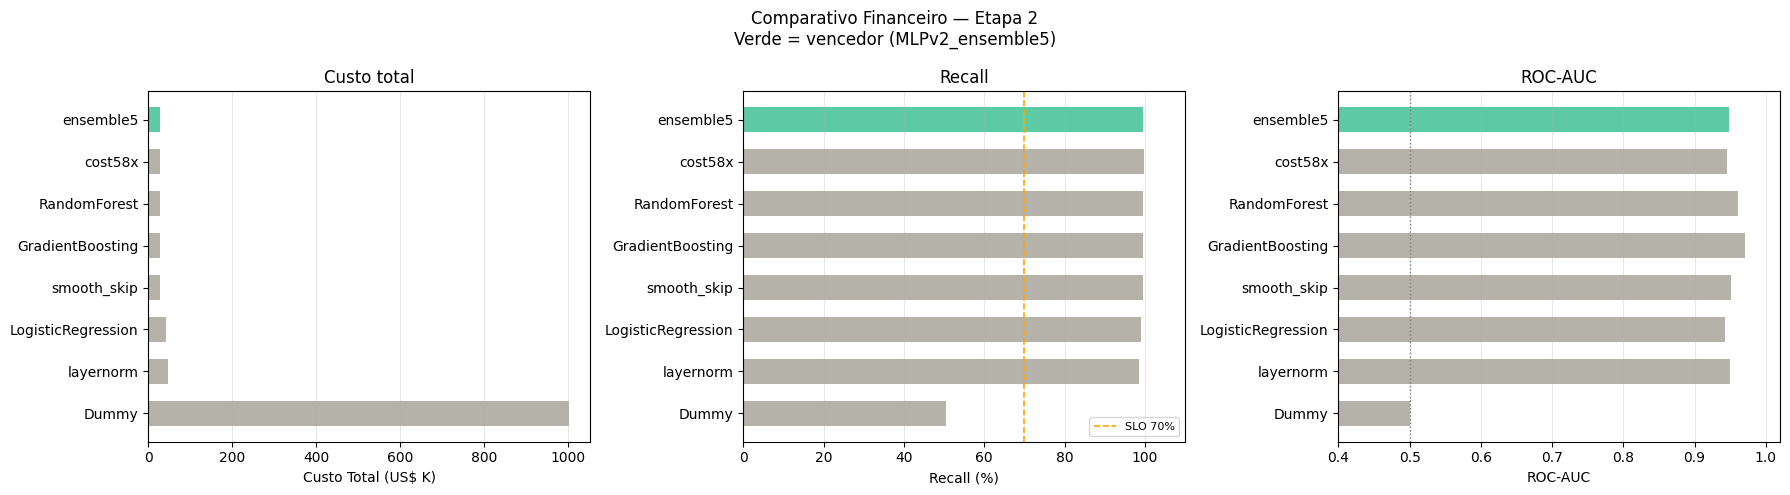

23:13:30 | INFO | Gráfico comparativo salvo
INFO:05_etapa2_completa:Gráfico comparativo salvo


In [11]:
FIGS_DIR = PROJECT_ROOT / "reports" / "baselines"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
names = df_comp["model"].tolist()
short = [n.replace("MLPv2_", "").replace("Classifier", "") for n in names]
colors = ["#5DCAA5" if n == winner_name else "#B4B2A9" for n in names]

ax = axes[0]
ax.barh(short, [c / 1e3 for c in df_comp["cost_total"]], color=colors, height=0.6)
ax.set(xlabel="Custo Total (US$ K)", title="Custo total")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

ax = axes[1]
ax.barh(short, df_comp["recall"] * 100, color=colors, height=0.6)
ax.axvline(70, color="orange", ls="--", lw=1.2, label="SLO 70%")
ax.set(xlabel="Recall (%)", title="Recall", xlim=(0, 110))
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

ax = axes[2]
ax.barh(short, df_comp["roc_auc"], color=colors, height=0.6)
ax.axvline(0.5, color="gray", ls=":", lw=1)
ax.set(xlabel="ROC-AUC", title="ROC-AUC", xlim=(0.4, 1.02))
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

fig.suptitle(f"Comparativo Financeiro — Etapa 2\nVerde = vencedor ({winner_name})", fontsize=12)
fig.tight_layout()
fig.savefig(FIGS_DIR / "comparativo_financeiro.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info("Gráfico comparativo salvo")

## 12. Optuna — 100 trials no modelo vencedor

Otimiza hiperparâmetros do modelo vencedor usando o critério financeiro: `minimize(cost_total)` com constraint `recall ≥ 70%`.

In [12]:
mlflow.end_run()
FIGS_DIR = PROJECT_ROOT / "reports" / "baselines"

is_mlp_winner = "MLP" in winner_name

if is_mlp_winner:
    def objective_mlp(trial):
        n_layers = trial.suggest_int("n_layers", 1, 3)
        dims = [trial.suggest_categorical(f"dim_{i}", [32, 64, 128]) for i in range(n_layers)]
        dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
        lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        batch = trial.suggest_categorical("batch_size", [64, 128, 256])
        pw = trial.suggest_float("pos_weight", 1.0, 80.0, log=True)
        wd = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        skip = trial.suggest_categorical("use_skip", [True, False])
        pat = trial.suggest_int("patience", 10, 30, step=5)

        fold_costs = []
        for fold, (tr_i, vl_i) in enumerate(SKF.split(X_dev, y_dev)):
            mdl = build_mlp_v2(X_dev.shape[1], dims, dropout, DEVICE, RANDOM_STATE + fold, skip)
            cfg = TrainerConfig(lr=lr, epochs=200, batch_size=batch, patience=pat, min_delta=1e-5,
                                weight_decay=wd, device=DEVICE, seed=RANDOM_STATE + fold, pos_weight=pw)
            t = ChurnTrainerV2(mdl, cfg)
            with mlflow.start_run(run_name=f"optuna_t{trial.number}_f{fold}", nested=True):
                t.fit(X_dev[tr_i], y_dev[tr_i], X_dev[vl_i], y_dev[vl_i])
            p = t.predict_proba(X_dev[vl_i])
            bt, _ = find_best_threshold(y_dev[vl_i], p)
            m = compute_metrics(y_dev[vl_i], p, bt)
            if m["recall"] < SLO_RECALL_MIN:
                return 1e8
            fold_costs.append(m["cost_total"])
        return float(np.mean(fold_costs))

    objective_fn = objective_mlp
else:
    # Vencedor é sklearn — otimizar RF ou GBM
    if "Forest" in winner_name:
        def objective_rf(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
                "max_depth": trial.suggest_int("max_depth", 3, 15),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            }
            fold_costs = []
            for _, (tr_i, vl_i) in enumerate(SKF.split(X_dev, y_dev)):
                clf = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
                clf.fit(X_dev[tr_i], y_dev[tr_i])
                p = clf.predict_proba(X_dev[vl_i])[:, 1]
                bt, _ = find_best_threshold(y_dev[vl_i], p)
                fold_costs.append(compute_metrics(y_dev[vl_i], p, bt)["cost_total"])
            return float(np.mean(fold_costs))
        objective_fn = objective_rf
    else:
        def objective_gbm(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
                "max_depth": trial.suggest_int("max_depth", 2, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            }
            fold_costs = []
            for _, (tr_i, vl_i) in enumerate(SKF.split(X_dev, y_dev)):
                clf = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
                clf.fit(X_dev[tr_i], y_dev[tr_i])
                p = clf.predict_proba(X_dev[vl_i])[:, 1]
                bt, _ = find_best_threshold(y_dev[vl_i], p)
                fold_costs.append(compute_metrics(y_dev[vl_i], p, bt)["cost_total"])
            return float(np.mean(fold_costs))
        objective_fn = objective_gbm

N_TRIALS = 100
with mlflow.start_run(run_name=f"optuna_{winner_name}_100trials") as optuna_run:
    mlflow.log_params(DATASET_META)
    mlflow.log_params({"n_trials": N_TRIALS, "objective": "minimize_cost_total", "winner_base": winner_name})

    study = optuna.create_study(
        study_name=f"churn_{winner_name}",
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    logger.info("Optuna | %d trials | modelo base: %s", N_TRIALS, winner_name)
    study.optimize(objective_fn, n_trials=N_TRIALS, show_progress_bar=True)

    mlflow.log_metrics({
        "optuna_best_cost_cv": study.best_value,
        "optuna_n_trials": N_TRIALS,
    })
    best_params_all[f"optuna_{winner_name}"] = study.best_params

    logger.info("Optuna concluído | best_cost=US$%.0f | params=%s", study.best_value, study.best_params)

# Salvar best params
params_path = MODELS_DIR / f"optuna_best_params_{winner_name}.json"
with open(params_path, "w") as f:
    json_mod.dump(study.best_params, f, indent=2, default=str)
logger.info("Best params salvos | %s", params_path)

23:13:30 | INFO | Optuna | 100 trials | modelo base: MLPv2_ensemble5
INFO:05_etapa2_completa:Optuna | 100 trials | modelo base: MLPv2_ensemble5


  0%|          | 0/100 [00:00<?, ?it/s]

23:13:30 | INFO | MLPv2 | dims=[32, 32] | params=2209 | skip=False | seed=42
INFO:05_etapa2_completa:MLPv2 | dims=[32, 32] | params=2209 | skip=False | seed=42
23:13:31 | INFO | fit | epochs=200 | batch=256 | train=4352 | val=1088
INFO:05_etapa2_completa:fit | epochs=200 | batch=256 | train=4352 | val=1088
23:13:31 | INFO | epoch 001 | tr=17.5499 | vl=7.5453 | auc=0.6736
INFO:05_etapa2_completa:epoch 001 | tr=17.5499 | vl=7.5453 | auc=0.6736
23:13:33 | INFO | epoch 025 | tr=1.3764 | vl=1.2540 | auc=0.9436
INFO:05_etapa2_completa:epoch 025 | tr=1.3764 | vl=1.2540 | auc=0.9436
23:13:35 | INFO | epoch 050 | tr=1.2620 | vl=1.1767 | auc=0.9463
INFO:05_etapa2_completa:epoch 050 | tr=1.2620 | vl=1.1767 | auc=0.9463
23:13:37 | INFO | epoch 075 | tr=1.1943 | vl=1.1422 | auc=0.9477
INFO:05_etapa2_completa:epoch 075 | tr=1.1943 | vl=1.1422 | auc=0.9477
23:13:38 | INFO | early stop | epoch=79 | best~=64
INFO:05_etapa2_completa:early stop | epoch=79 | best~=64
23:13:38 | INFO | MLPv2 | dims=[32, 32

## 13. Retreinar vencedor otimizado → avaliação final no test set

In [13]:
FIGS_DIR = PROJECT_ROOT / "reports" / "baselines"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.end_run()

with mlflow.start_run(run_name=f"etapa2_winner_{winner_name}_optuna") as final_run:
    mlflow.log_params(DATASET_META)
    mlflow.log_params({f"opt_{k}": str(v) for k, v in study.best_params.items()})
    mlflow.set_tag("etapa", "2_winner")

    bp = study.best_params

    if is_mlp_winner:
        dims = [bp[f"dim_{i}"] for i in range(bp["n_layers"])]
        X_tr, X_vl, y_tr, y_vl = train_test_split(
            X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
        )
        model_w = build_mlp_v2(INPUT_DIM, dims, bp["dropout"], DEVICE, RANDOM_STATE, bp["use_skip"])
        cfg_w = TrainerConfig(
            lr=bp["lr"], epochs=300, batch_size=bp["batch_size"],
            patience=bp["patience"], min_delta=1e-5,
            weight_decay=bp["weight_decay"], device=DEVICE,
            seed=RANDOM_STATE, pos_weight=bp["pos_weight"],
        )
        trainer_w = ChurnTrainerV2(model_w, cfg_w)
        hist_w = trainer_w.fit(X_tr, y_tr, X_vl, y_vl)
        y_proba_w = trainer_w.predict_proba(X_test)
        mlflow.log_metric("best_epoch", hist_w.best_epoch)

        # Salvar checkpoint
        pt_path = MODELS_DIR / "best_mlp_etapa2.pt"
        torch.save(model_w.state_dict(), pt_path)
        mlflow.log_artifact(str(pt_path), "model")
        logger.info("MLP salvo | %s", pt_path)
    else:
        if "Forest" in winner_name:
            clf_w = RandomForestClassifier(**bp, random_state=RANDOM_STATE, n_jobs=-1)
        else:
            clf_w = GradientBoostingClassifier(**bp, random_state=RANDOM_STATE)
        clf_w.fit(X_dev, y_dev)
        y_proba_w = clf_w.predict_proba(X_test)[:, 1]

        import joblib
        pkl_path = MODELS_DIR / f"best_{winner_name}_etapa2.pkl"
        joblib.dump(clf_w, pkl_path)
        mlflow.log_artifact(str(pkl_path), "model")
        logger.info("Modelo salvo | %s", pkl_path)

    result_w = evaluate_and_log(
        f"{winner_name}_optuna", y_test, y_proba_w, FIGS_DIR,
        extra_metrics={"optuna_best_cost_cv": study.best_value},
    )
    result_w["type"] = "Winner (Optuna)"
    all_results.append(result_w)

    # Salvar tabela final
    comp_path = MODELS_DIR / "model_comparison_etapa2.csv"
    pd.DataFrame(all_results).sort_values("cost_total").to_csv(comp_path, index=False)
    mlflow.log_artifact(str(comp_path), "reports")
    mlflow.log_artifact(str(FIGS_DIR / "comparativo_financeiro.png"), "plots")

logger.info(
    "VENCEDOR FINAL | %s_optuna | custo=US$%.0f | recall=%.1f%% | fn=%d",
    winner_name, result_w["cost_total"], result_w["recall"] * 100, result_w["fn"],
)

00:02:39 | INFO | MLPv2 | dims=[64, 32] | params=5281 | skip=True | seed=42
INFO:05_etapa2_completa:MLPv2 | dims=[64, 32] | params=5281 | skip=True | seed=42
00:02:39 | INFO | fit | epochs=300 | batch=256 | train=4352 | val=1088
INFO:05_etapa2_completa:fit | epochs=300 | batch=256 | train=4352 | val=1088
00:02:39 | INFO | epoch 001 | tr=1.8783 | vl=1.0080 | auc=0.9298
INFO:05_etapa2_completa:epoch 001 | tr=1.8783 | vl=1.0080 | auc=0.9298
00:02:41 | INFO | epoch 025 | tr=0.5866 | vl=0.7893 | auc=0.9561
INFO:05_etapa2_completa:epoch 025 | tr=0.5866 | vl=0.7893 | auc=0.9561
00:02:42 | INFO | early stop | epoch=36 | best~=21
INFO:05_etapa2_completa:early stop | epoch=36 | best~=21
00:02:42 | INFO | MLP salvo | C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlp_etapa2.pt
INFO:05_etapa2_completa:MLP salvo | C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlp_etapa2

## 14. Resumo executivo

In [14]:
df_final = pd.DataFrame(all_results).sort_values("cost_total").reset_index(drop=True)

logger.info("=" * 60)
logger.info("ETAPA 2 CONCLUÍDA")
logger.info("=" * 60)
logger.info("Modelos avaliados    : %d", len(df_final))
logger.info("Vencedor             : %s", result_w["model"])
logger.info("Custo total          : US$%.0f", result_w["cost_total"])
logger.info("Recall               : %.1f%%", result_w["recall"] * 100)
logger.info("ROC-AUC              : %.4f", result_w["roc_auc"])
logger.info("FN (churners perdidos): %d", result_w["fn"])
logger.info("SLO (≥70%%)           : %s", "OK" if result_w["slo_ok"] else "VIOLADO")
logger.info("Optuna trials        : %d", N_TRIALS)
logger.info("Optuna best cost CV  : US$%.0f", study.best_value)
logger.info("=" * 60)
logger.info("Entregáveis:")
logger.info("  [x] Tabela comparativa  → models/model_comparison_etapa2.csv")
logger.info("  [x] MLP treinada        → models/best_mlp_etapa2.pt")
logger.info("  [x] Artefatos MLflow    → experiment '%s'", MLFLOW_EXPERIMENT)
logger.info("  [x] Gráficos            → reports/baselines/")
logger.info("  [x] Model Card          → célula 15 deste notebook")
logger.info("Próximo: Etapa 3 — Refatoração src/, FastAPI, testes pytest")

00:02:43 | INFO | ============================================================
INFO:05_etapa2_completa:============================================================
00:02:43 | INFO | ETAPA 2 CONCLUÍDA
INFO:05_etapa2_completa:ETAPA 2 CONCLUÍDA
00:02:43 | INFO | ============================================================
INFO:05_etapa2_completa:============================================================
00:02:43 | INFO | Modelos avaliados    : 9
INFO:05_etapa2_completa:Modelos avaliados    : 9
00:02:43 | INFO | Vencedor             : MLPv2_ensemble5_optuna
INFO:05_etapa2_completa:Vencedor             : MLPv2_ensemble5_optuna
00:02:43 | INFO | Custo total          : US$24732
INFO:05_etapa2_completa:Custo total          : US$24732
00:02:43 | INFO | Recall               : 99.7%
INFO:05_etapa2_completa:Recall               : 99.7%
00:02:43 | INFO | ROC-AUC              : 0.9541
INFO:05_etapa2_completa:ROC-AUC              : 0.9541
00:02:43 | INFO | FN (churners perdidos): 2
INFO:05_etapa2_c

## 15. Model Card

### Informações

| Campo | Valor |
|---|---|
| Nome | ChurnMLPv2 (ou modelo vencedor pós-Optuna) |
| Tarefa | Classificação binária — previsão de churn telecom |
| Dataset | Telco Customer Churn (IBM) · n=7.043 · 30 features |
| Critério primário | Minimizar custo total: FN × US\$2.903 + FP × US\$50 |
| SLO | Recall ≥ 70% |
| Avaliação | StratifiedKFold 5-fold + hold-out 20% |
| Otimização | Optuna TPE 100 trials no modelo vencedor |

### Arquitetura MLP

```
Input(30) → [Linear → LayerNorm → ReLU → Dropout] × L → Linear(1) → logit
Loss: BCEWithLogitsLoss(pos_weight=58×)
Optimizer: AdamW(lr, weight_decay)
Early stopping: patience=25, monitor=val_loss
```

### Limitações

1. **Threshold calibrado para a distribuição de treino** (~26.5% churn). Recalibrar se a taxa real divergir.
2. **Features estáticas**: snapshot do cliente, sem dinâmica temporal.
3. **Generalização geográfica**: dataset norte-americano. Outros mercados exigem retreinamento.
4. **Dados ausentes**: preprocessor usa mediana, mas features críticas ausentes podem degradar predições.
5. **Probabilidades não calibradas**: saídas são scores ordinais, não probabilidades absolutas.

### Vieses documentados

1. **Viés de custo intencional**: modelo enviesado para minimizar FN (58× mais caros que FP).
2. **Viés de contrato**: clientes Month-to-month têm churn ~43% vs ~11% anuais — possível proxy.
3. **Viés de gênero**: coluna `gender` mantida sem análise de impacto diferencial.
4. **Viés de antiguidade**: clientes novos sobre-representados nos churners.

### Cenários de falha

- `tenure_months = 0`: probabilidades instáveis
- `total_charges ≤ 0`: log1p no preprocessor pode gerar anomalias
- Drift de produto: mudanças no portfólio invalidam features

### Plano de monitoramento

| Métrica | Frequência | Alerta |
|---|---|---|
| Recall realizado | Mensal | < 70% |
| PSI do score | Semanal | > 0.20 |
| Churn real vs predito | Mensal | Delta > 5 pp |
| Custo real vs estimado | Trimestral | Divergência > 20% |
| KS test das features | Semanal | p < 0.05 em ≥ 3 features |